# Машинное обучение, ФКН ВШЭ

## Практическое задание 5. Решающие деревья

### Общая информация
Дата выдачи: 29.11.2023

Мягий дедлайн: 23:59 12.12.2023

Жестокий дедлайн: 23:59 14.12.2023

### О задании

Задание состоит из двух разделов:
1. В первом разделе вы научитесь применять деревья из sklearn для задачи классификации. Вы посмотрите какие разделяющие поверхности деревья строят для различных датасетов и проанализируете их зависимость от различных гиперпараметров.
2. Во втором разделе вы попробуете реализовать свое решающее дерево и сравните его со стандартное имплиментацией из sklearn. Вы также протестируете деревья на более сложных датасетах и сравните различные подходы к кодированию категориальных признаков.

### Оценивание и штрафы
Каждая из задач имеет определенную «стоимость» (указана в скобках около задачи). Максимально допустимая оценка за работу — 10 баллов.

Сдавать задание после указанного срока сдачи нельзя. При выставлении неполного балла за задание в связи с наличием ошибок на усмотрение проверяющего предусмотрена возможность исправить работу на указанных в ответном письме условиях.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов (подробнее о плагиате см. на странице курса). Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).

Неэффективная реализация кода может негативно отразиться на оценке.


### Формат сдачи
Задания сдаются через систему anytask. Посылка должна содержать:
* Ноутбук homework-practice-05-trees-Username.ipynb
* Модуль hw5code.py
* Ссылки на посылки в Яндекс.Контесте для обеих задач

В контест https://contest.yandex.ru/contest/56884/problems/ нужно отправить файл hw5code.py с реализованными функциями и классами.

Username — ваша фамилия и имя на латинице именно в таком порядке

Для удобства проверки самостоятельно посчитайте свою максимальную оценку (исходя из набора решенных задач) и укажите ниже:

__Оценка:__

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from matplotlib.colors import Colormap, ListedColormap
import pandas as pd
from sklearn.model_selection import train_test_split
import seaborn as sns
sns.set(style='whitegrid')

import warnings
warnings.filterwarnings('ignore')

# 1. Решающие деревья. Визуализация.

В этой части мы рассмотрим два простых двумерных датасета сделанных с помощью `make_moons`, `make_circles` и посмотрим как ведет себя разделяющая поверхность в зависимости от различных гиперпараметров.

In [2]:
from sklearn.datasets import make_moons, make_circles, make_classification
datasets = [
    make_circles(noise=0.2, factor=0.5, random_state=42),
    make_moons(noise=0.2, random_state=42),
    make_classification(n_classes=3, n_clusters_per_class=1, n_features=2, class_sep=.8, random_state=3,
                        n_redundant=0)
]

In [3]:
palette = sns.color_palette(n_colors=3)
cmap = ListedColormap(palette)

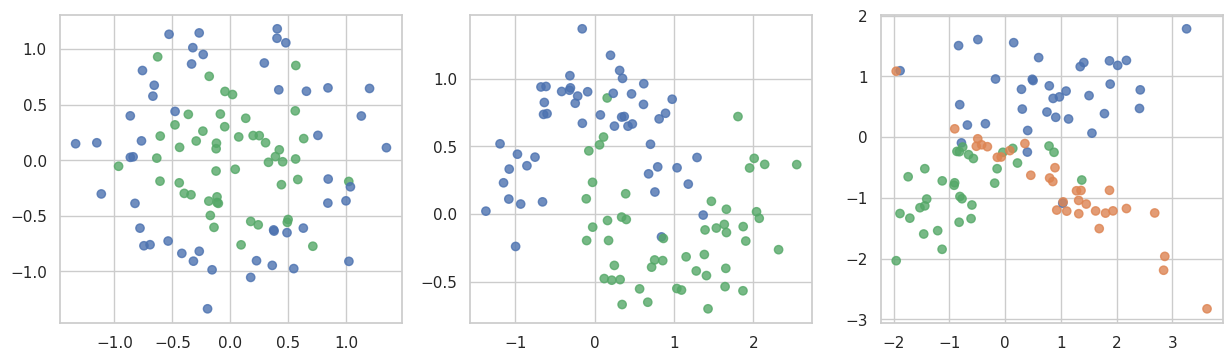

In [4]:
plt.figure(figsize=(15, 4))
for i, (x, y) in enumerate(datasets):
    plt.subplot(1, 3, i + 1)
    plt.scatter(x[:, 0], x[:, 1], c=y, cmap=cmap, alpha=.8)

__Задание 1. (1 балл)__

Для каждого датасета обучите решающее дерево с параметрами по умолчанию, предварительно разбив выборку на обучающую и тестовую. Постройте разделящие поверхности (для этого воспользуйтесь функцией `plot_surface`, пример ниже). Посчитайте accuracy на обучающей и тестовой выборках. Сильно ли деревья переобучились?

In [5]:
def plot_surface(clf, X, y):
    plot_step = 0.01
    palette = sns.color_palette(n_colors=len(np.unique(y)))
    cmap = ListedColormap(palette)
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                         np.arange(y_min, y_max, plot_step))
    plt.tight_layout(h_pad=0.5, w_pad=0.5, pad=2.5)

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    cs = plt.contourf(xx, yy, Z, cmap=cmap, alpha=0.3)

    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap, alpha=.7,
                edgecolors=np.array(palette)[y], linewidths=2)

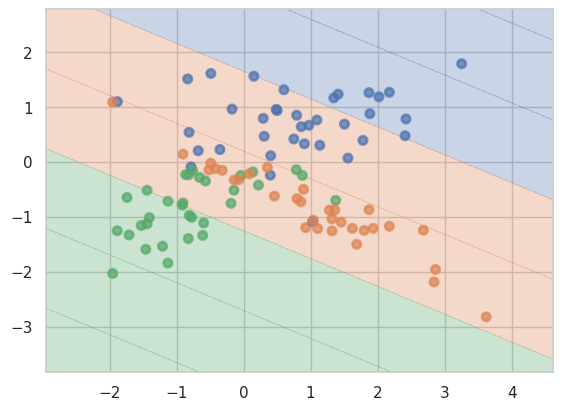

In [6]:
# Пример:
from sklearn.linear_model import LinearRegression
X, y = datasets[2]
lr  = LinearRegression().fit(X, y)
plt.subplot()
plot_surface(lr, X, y)

In [7]:
def get_accuracy(clf, X_train, y_train, X_test, y_test):
  pred_train = clf.predict(X_train)
  pred_test = clf.predict(X_test)
  accuracy_train = (y_train == pred_train).sum() / y_train.shape[0]
  accuracy_test = (y_test == pred_test).sum() / y_test.shape[0]
  return accuracy_train, accuracy_test


for dataset 1 accuracy is:
 train: 1.0
 test: 0.88
for dataset 2 accuracy is:
 train: 1.0
 test: 0.9
for dataset 3 accuracy is:
 train: 1.0
 test: 0.8


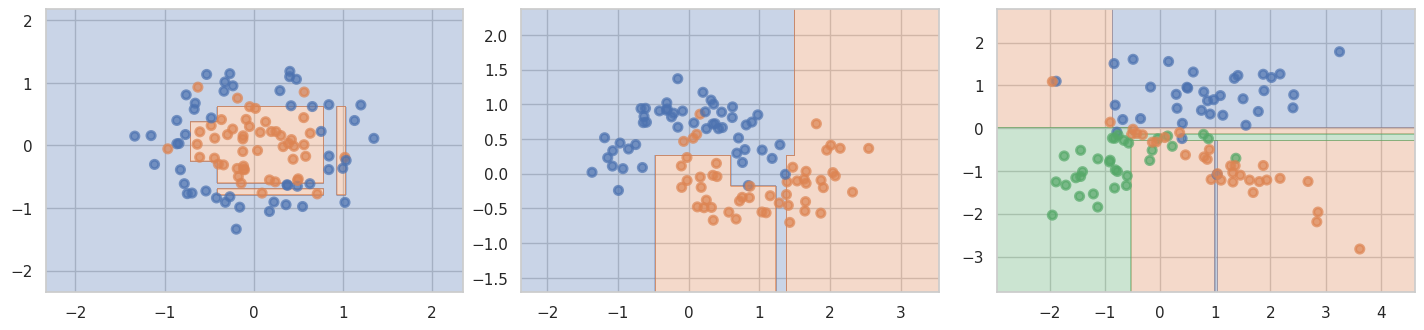

In [8]:
from sklearn.tree import DecisionTreeClassifier
plt.figure(figsize=(15, 4))
for i, (X, y) in enumerate(datasets):
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=67)
  tree = DecisionTreeClassifier()
  tree.fit(X_train, y_train)
  plt.subplot(1, 3, i + 1)
  plot_surface(tree, X, y)
  accuracy_train, accuracy_test = get_accuracy(tree, X_train, y_train, X_test, y_test)
  print(f"for dataset {i+1} accuracy is:\n train: {accuracy_train}\n test: {accuracy_test}")



__Ответ:__

__Задание 2. (1.5 балла)__

Попробуйте перебрать несколько параметров для регуляризации (напр. `max_depth`, `min_samples_leaf`). Для каждого набора гиперпараметров постройте разделяющую поверхность, выведите обучающую и тестовую ошибки. Можно делать кросс-валидацию или просто разбиение на трейн и тест, главное делайте каждый раз одинаковое разбиение, чтобы можно было корректно сравнивать (помните же, что итоговое дерево сильно зависит от небольшого изменения обучающей выборки?). Проследите как меняется разделяющая поверхность и обобщающая способность. Почему так происходит, одинаково ли изменение для разных датасетов?

for dataset 1 accuracy is:
 train: 0.92
 test: 0.76
for dataset 2 accuracy is:
 train: 0.98
 test: 0.86
for dataset 3 accuracy is:
 train: 0.98
 test: 0.84
for dataset 1 accuracy is:
 train: 0.92
 test: 0.76
for dataset 2 accuracy is:
 train: 0.88
 test: 0.74
for dataset 3 accuracy is:
 train: 0.9
 test: 0.84
for dataset 1 accuracy is:
 train: 0.78
 test: 0.7
for dataset 2 accuracy is:
 train: 0.88
 test: 0.74
for dataset 3 accuracy is:
 train: 0.9
 test: 0.84
for dataset 1 accuracy is:
 train: 1.0
 test: 0.82
for dataset 2 accuracy is:
 train: 1.0
 test: 0.86
for dataset 3 accuracy is:
 train: 1.0
 test: 0.8
for dataset 1 accuracy is:
 train: 0.92
 test: 0.76
for dataset 2 accuracy is:
 train: 0.88
 test: 0.74
for dataset 3 accuracy is:
 train: 0.9
 test: 0.84
for dataset 1 accuracy is:
 train: 0.78
 test: 0.7
for dataset 2 accuracy is:
 train: 0.88
 test: 0.74
for dataset 3 accuracy is:
 train: 0.9
 test: 0.84
for dataset 1 accuracy is:
 train: 1.0
 test: 0.86
for dataset 2 accuracy 

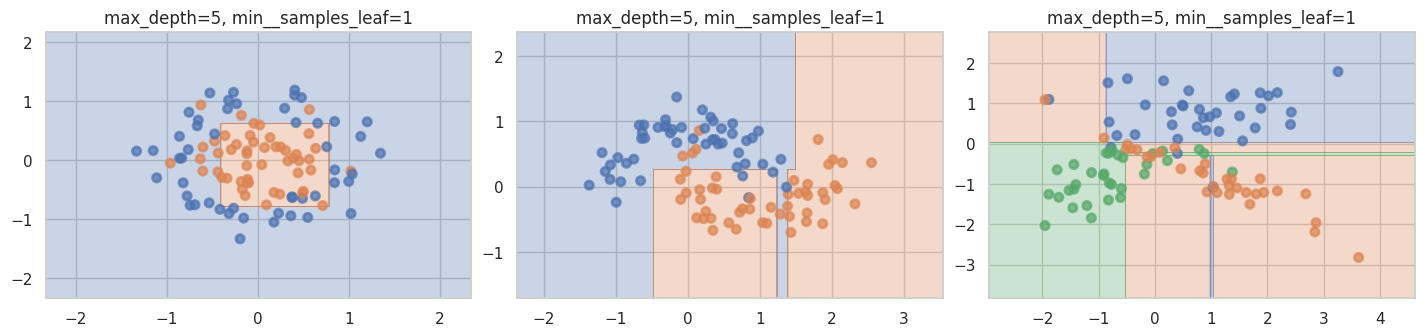

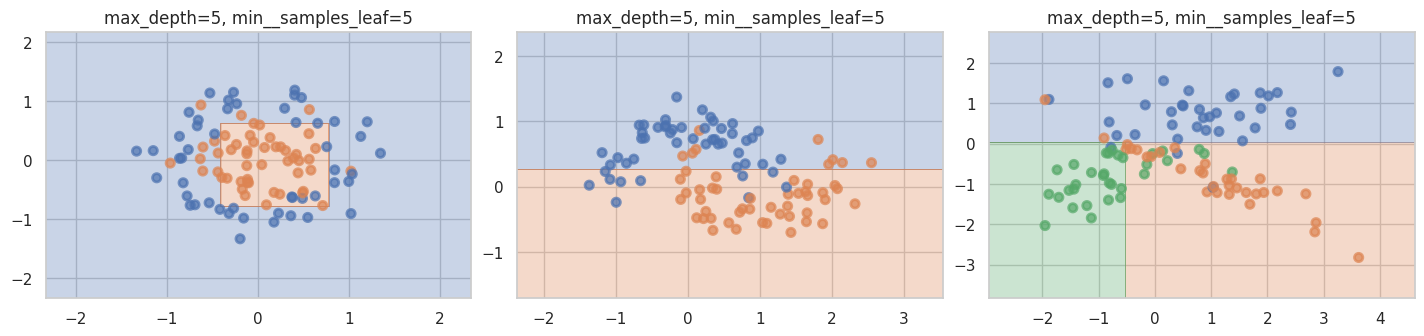

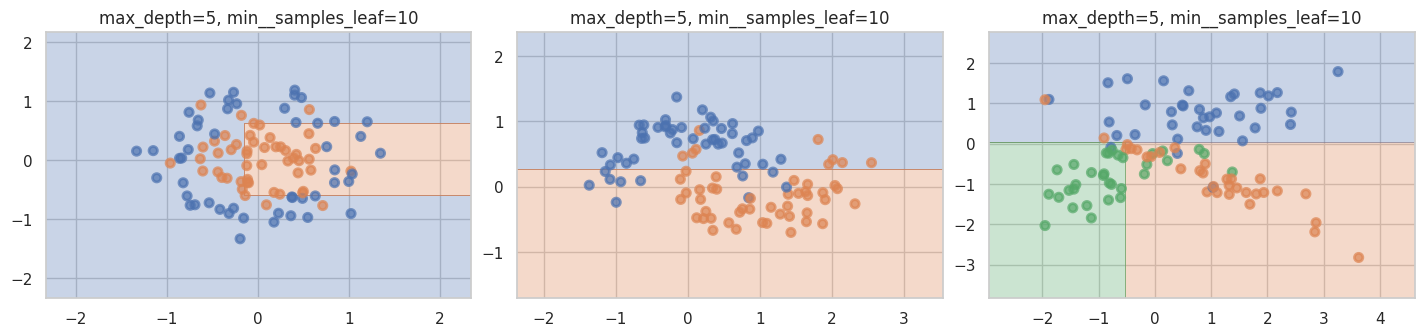

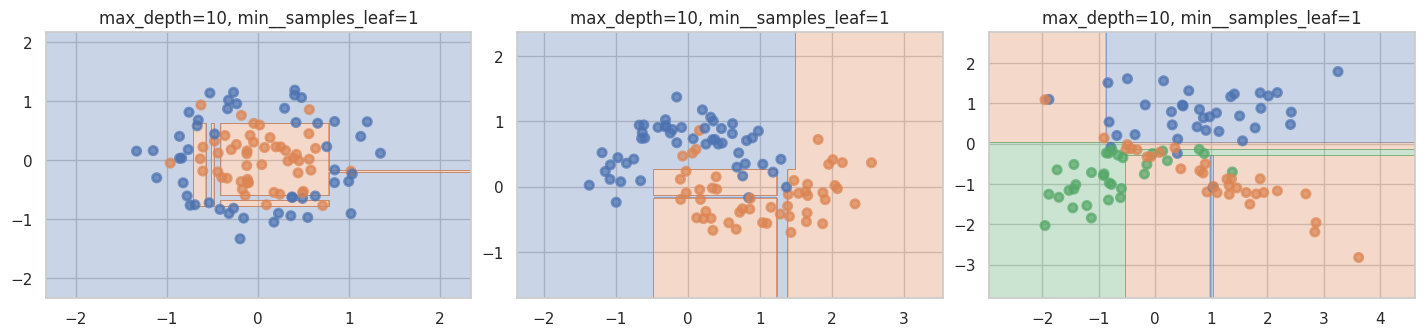

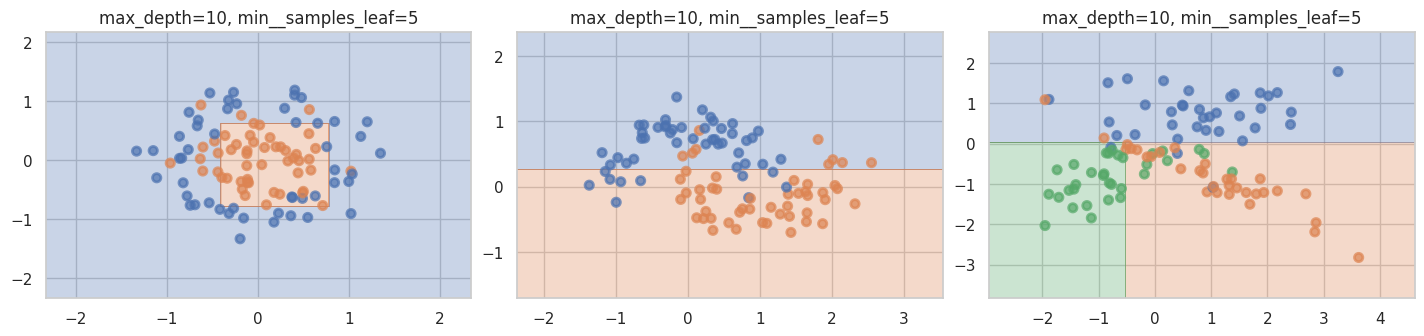

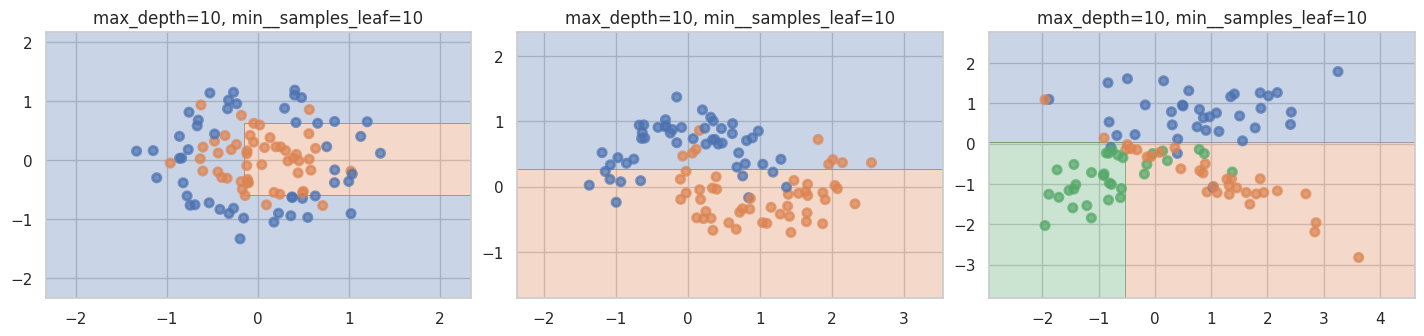

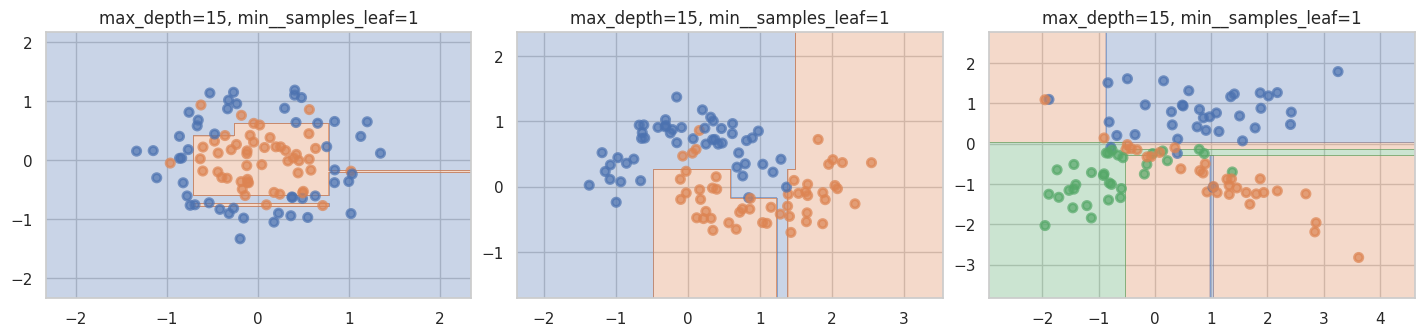

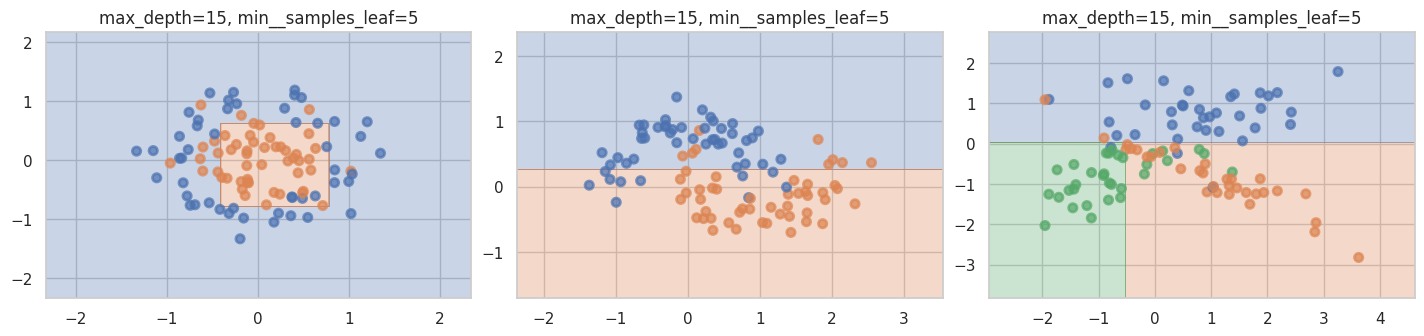

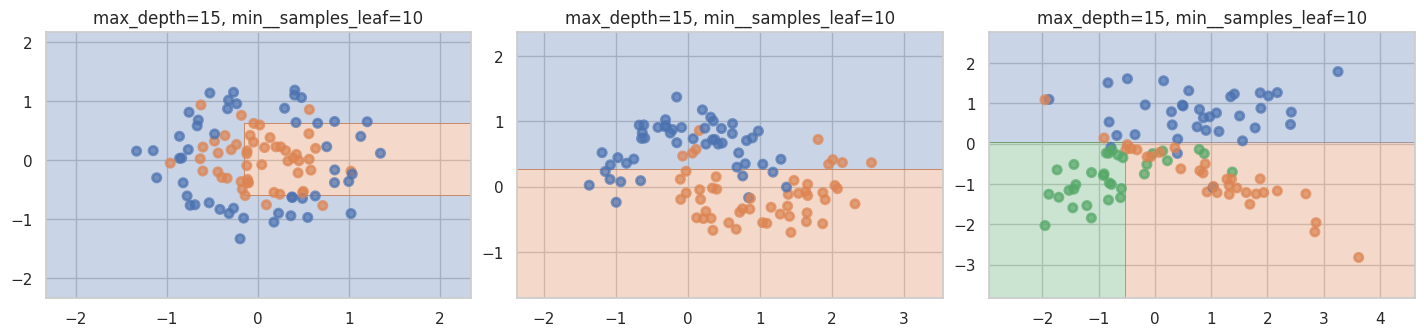

In [9]:
from sklearn.tree import DecisionTreeClassifier

depths = [ 5, 10, 15]
leafs = [1, 5, 10]

for d in depths:
  for l in leafs:
    plt.figure(figsize=(15, 4))
    for i, (X, y) in enumerate(datasets):
      X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=67)
      tree = DecisionTreeClassifier(max_depth=d, min_samples_leaf=l)
      tree.fit(X_train, y_train)
      plt.subplot(1, 3, i + 1)
      plt.title(f"max_depth={d}, min__samples_leaf={l}")
      plot_surface(tree, X, y)
      accuracy_train, accuracy_test = get_accuracy(tree, X_train, y_train, X_test, y_test)
      print(f"for dataset {i+1} accuracy is:\n train: {accuracy_train}\n test: {accuracy_test}")



__Ответ:__

# 2. Решающие деревья своими руками

В этой части вам нужно реализовать свой класс для обучения решающего дерева в задаче бинарной классификации с возможностью обработки вещественных и категориальных признаков.

__Задание 3. (1.5 балл)__

Реализуйте функцию find_best_split из модуля hw5code.py

__Задание 4. (0.5 балла)__

Загрузите таблицу [students.csv](https://github.com/esokolov/ml-course-hse/blob/master/2022-fall/homeworks-practice/homework-practice-05-trees/students.csv) (это немного преобразованный датасет [User Knowledge](https://archive.ics.uci.edu/ml/datasets/User+Knowledge+Modeling)). В ней признаки объекта записаны в первых пяти столбцах, а в последнем записана целевая переменная (класс: 0 или 1). Постройте на одном изображении пять кривых "порог — значение критерия Джини" для всех пяти признаков. Отдельно визуализируйте scatter-графики "значение признака — класс" для всех пяти признаков.

In [10]:
df = pd.read_csv("students.csv")
df.head()


,STG,SCG,STR,LPR,PEG,UNS
0,0.00,0.00,0.00,0.00,0.00,0
1,0.08,0.08,0.10,0.24,0.90,1
2,0.06,0.06,0.05,0.25,0.33,0
3,0.10,0.10,0.15,0.65,0.30,1
4,0.08,0.08,0.08,0.98,0.24,0


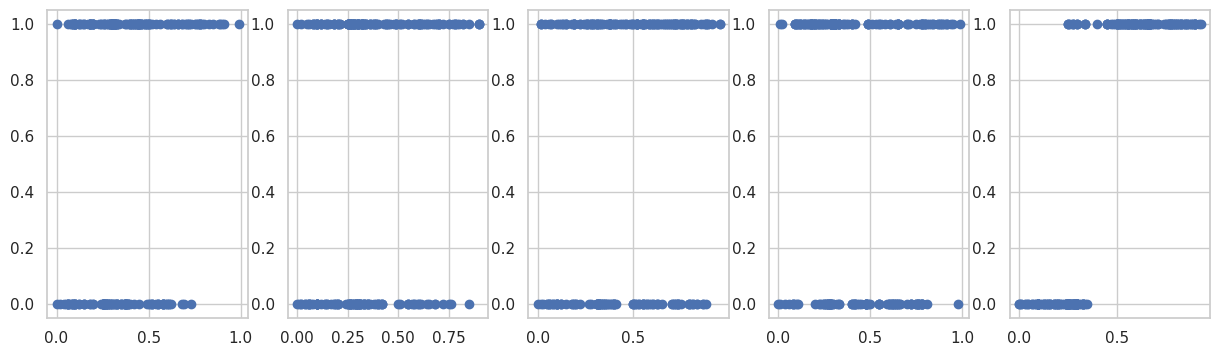

In [11]:

features = ['STG', 'SCG', 'STR', 'LPR', 'PEG']
target = 'UNS'
plt.figure(figsize=(15, 4))
for i, f in enumerate(features):
  plt.subplot(1, 5, i + 1)
  plt.scatter(df[f], df[target])

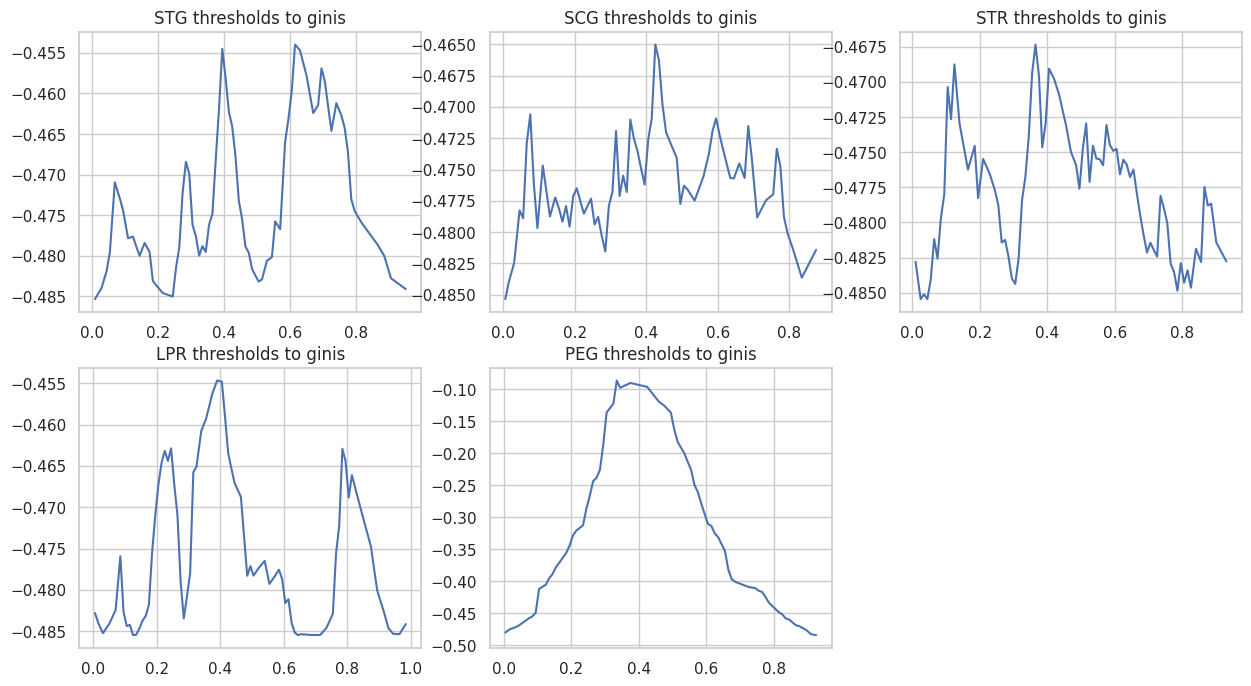

In [12]:
from hw5code import find_best_split, DecisionTree

plt.figure(figsize=(15, 8))
for i, f in enumerate(features):
  thresholds, ginis, _, _ = find_best_split(df[f], df[target])
  plt.subplot(2, 3, i + 1)
  plt.plot(thresholds, ginis)
  plt.title(f"{f} thresholds to ginis")

__Задание 5. (0.5 балла)__

Исходя из кривых значений критерия Джини, по какому признаку нужно производить деление выборки на два поддерева? Согласуется ли этот результат с визуальной оценкой scatter-графиков? Как бы охарактеризовали вид кривой для "хороших" признаков, по которым выборка делится почти идеально? Чем отличаются кривые для признаков, по которым деление практически невозможно?

**Ответ:**

__Задание 6. (1.5 балла).__

Разберитесь с уже написанным кодом в классе DecisionTree модуля hw5code.py. Найдите ошибки в реализации метода \_fit_node. Напишите функцию \_predict_node.

 Построение дерева осуществляется согласно базовому жадному алгоритму, предложенному в [лекции](https://github.com/esokolov/ml-course-hse/blob/master/2020-fall/lecture-notes/lecture07-trees.pdf) в разделе «Построение дерева». Выбор лучшего разбиения необходимо производить по критерию Джини. Критерий останова: все объекты в листе относятся к одному классу или ни по одному признаку нельзя разбить выборку. Ответ в листе: наиболее часто встречающийся класс в листе. Для категориальных признаков выполняется преобразование, описанное в лекции в разделе «Учет категориальных признаков».

__Задание 7. (0.5 балла)__

Протестируйте свое решающее дерево на датасете [mushrooms](https://archive.ics.uci.edu/ml/datasets/Mushroom). Вам нужно скачать таблицу agaricus-lepiota.data (лежит на гитхабе вместе с заданием), прочитать ее с помощью pandas, применить к каждому столбцу LabelEncoder (из sklearn), чтобы преобразовать строковые имена категорий в натуральные числа. Первый столбец — это целевая переменная (e — edible, p — poisonous) Мы будем измерять качество с помощью accuracy, так что нам не очень важно, что будет классом 1, а что — классом 0. Обучите решающее дерево на половине случайно выбранных объектов (признаки в датасете категориальные) и сделайте предсказания для оставшейся половины. Вычислите accuracy.

У вас должно получиться значение accuracy, равное единице (или очень близкое к единице), и не очень глубокое дерево.

In [13]:
df = pd.read_csv("agaricus-lepiota.data")

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

X = df.drop(['p'], axis=1)

for col in X.columns:
  X[col] = encoder.fit_transform(X[col])
  X[col] = X[col].astype('category')

y = (df['p'] == 'p').astype(int)


In [14]:
X_train, X_test, y_train, y_test = train_test_split(X.values, y.values, test_size=0.5,
                                                    random_state=52)


tree = DecisionTree(feature_types=["categorical"]*X.shape[1])

tree.fit(X_train, y_train)

pred = tree.predict(X_test)

accuracy = np.mean(pred == y_test)
print(accuracy)

1.0


ПОГОДИТЕ, ЭТО РЕАЛЬНО?

__Задание 8. (бонус, 1 балл)__

Реализуйте в классе DecisionTree поддержку параметров max_depth, min_samples_split и min_samples_leaf по аналогии с DecisionTreeClassifier. Постройте графики зависимости качества предсказания в зависимости от этих параметров для набора данных tic-tac-toe (см. следующий пункт).

__Задание 9. (2 балла)__

Загрузите следующие наборы данных (напомним, что pandas умеет загружать файлы по url, в нашем случае это файл \*.data), предварительно ознакомившись с описанием признаков и целевой переменной в каждом из них (она записаны в Data Folder, в файле *.names): 
* [mushrooms](https://archive.ics.uci.edu/ml/datasets/Mushroom) (загрузили в предыдущем пункте, классы записаны в нулевом столбце)
* [tic-tac-toe](https://archive.ics.uci.edu/ml/datasets/Tic-Tac-Toe+Endgame) (классы записаны в последнем столбце, датасет лежит на гитхабе вместе с заданием)
* [cars](https://archive.ics.uci.edu/ml/datasets/Car+Evaluation) (классы записаны в последнем столбце, считаем что unacc, acc — это класс 0, good, vgood — класс 1)
* [nursery](https://archive.ics.uci.edu/ml/datasets/Nursery) (классы записаны в последнем столбце, считаем, что not_recom и recommend — класс 0, very_recom, priority, spec_prior — класс 1).

Закодируйте категориальные признаки, использовав LabelEncoder. С помощью cross_val_score (cv=10) оцените accuracy на каждом из этих наборов данных следующих алгоритмов:
* DecisionTree, считающий все признаки вещественными
* DecisionTree, считающий все признаки категориальными
* DecisionTree, считающий все признаки вещественными + one-hot-encoding всех признаков
* DecisionTreeClassifier из sklearn. Запишите результат в pd.DataFrame (по строкам — наборы данных, по столбцам — алгоритмы).

Рекомендации:
* Чтобы cross_val_score вычисляла точность, нужно передать scoring=make_scorer(accuracy_score), обе фукнции из sklearn.metrics.
* Если вам позволяет память (а она скорее всего позволяет), указывайте параметр sparse=False в OneHotEncoder (если вы, конечно, используете его). Иначе вам придется добиваться того, чтобы ваша реализация дерева умела работать с разреженными матрицами (что тоже, в целом, не очень сложно).

In [15]:
cars = pd.read_csv("car.data")
cars
X = cars.drop(["unacc"], axis=1)
y = (cars["unacc"].isin(['good', 'vgood'])).astype(int)
cat_cols = X.select_dtypes(include=['object', 'category']).columns
for col in cat_cols:
    encoder = LabelEncoder()
    X[col] = encoder.fit_transform(X[col])

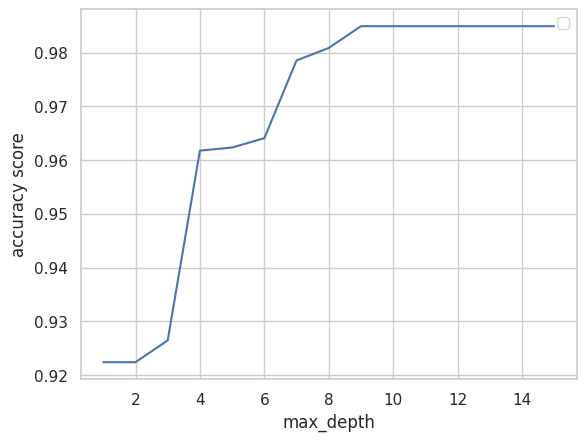

In [20]:
from sklearn.model_selection import cross_val_score

from sklearn.model_selection import KFold

kf = KFold(n_splits=10, shuffle=True, random_state=42)

depths = np.linspace(1, 15, 15, dtype=int)

X_np = X.values
y_np = y.values

accuracy_scores = []

for max_depth in depths:
  scores = []
  for train_idx, test_idx in kf.split(X_np):
    X_train, y_train = X_np[train_idx], y_np[train_idx]
    X_test, y_test = X_np[test_idx], y_np[test_idx]
    tree = DecisionTree(feature_types=["categorical"] * X.shape[1], max_depth=max_depth)
    tree.fit(X_train, y_train)
    pred = tree.predict(X_test)
    accuracy = np.mean((pred == y_test).astype(int))
    scores.append(accuracy)
  accuracy_scores.append(np.mean(scores))

plt.plot(depths, accuracy_scores)
plt.xlabel("max_depth")
plt.ylabel("accuracy score")
plt.legend()
plt.show()

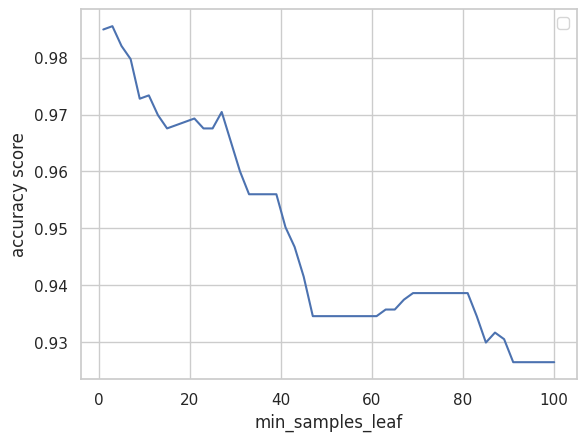

In [22]:
samples = np.linspace(1, 100, 50, dtype=int)

accuracy_scores = []

for min_samples_leaf in samples:
  scores = []
  for train_idx, test_idx in kf.split(X_np):
    X_train, y_train = X_np[train_idx], y_np[train_idx]
    X_test, y_test = X_np[test_idx], y_np[test_idx]
    tree = DecisionTree(feature_types=["categorical"] * X.shape[1], min_samples_leaf=min_samples_leaf)
    tree.fit(X_train, y_train)
    pred = tree.predict(X_test)
    accuracy = np.mean((pred == y_test).astype(int))
    scores.append(accuracy)
  accuracy_scores.append(np.mean(scores))

plt.plot(samples, accuracy_scores)
plt.xlabel("min_samples_leaf")
plt.ylabel("accuracy score")
plt.legend()
plt.show()

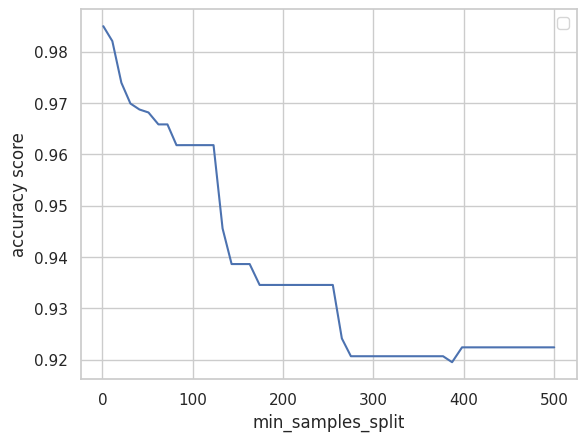

In [25]:
samples = np.linspace(1, 500, 50, dtype=int)

accuracy_scores = []

for min_samples_split in samples:
  scores = []
  for train_idx, test_idx in kf.split(X_np):
    X_train, y_train = X_np[train_idx], y_np[train_idx]
    X_test, y_test = X_np[test_idx], y_np[test_idx]
    tree = DecisionTree(feature_types=["categorical"] * X.shape[1], min_samples_split=min_samples_split)
    tree.fit(X_train, y_train)
    pred = tree.predict(X_test)
    accuracy = np.mean((pred == y_test).astype(int))
    scores.append(accuracy)
  accuracy_scores.append(np.mean(scores))

plt.plot(samples, accuracy_scores)
plt.xlabel("min_samples_split")
plt.ylabel("accuracy score")
plt.legend()
plt.show()

__Задание 10. (1 балла)__

Проанализируйте результаты эксперимента. 
Одинаково ли для разных наборов данных ранжируются алгоритмы? 
Порассуждайте, почему так происходит. 

Обратите внимание на значение признаков в разных наборах данных. 
Присутствует ли в результатах какая-то компонента случайности? 
Можно ли повлиять на нее и улушить работу алгоритмов?

**Ответ:**

Вставьте что угодно, описывающее ваши впечатления от этого задания: